# U07 | GRU 原理与公式推导

**本单元目标**：理解 GRU 如何解决 RNN 的梯度消失问题，掌握 4 个核心公式。

1. 为什么 RNN 不够用 —— 梯度消失的根源
2. GRU 的门控思想 —— 让模型自己决定记什么忘什么
3. 4 个公式逐一推导
4. PyTorch `nn.GRU` 用法

**过关标准**：能默写 4 个 GRU 公式并解释每一项含义。

---

## 1. 回顾 RNN 的问题

U06 学的 RNN 公式：

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b)$$

每一步把「当前词」和「上一步记忆」混合。

### 梯度消失（Gradient Vanishing）

序列展开后，反向传播要穿越很多个 tanh：

```
dL/dh1 = dL/dh10 * dh10/dh9 * dh9/dh8 * ... * dh2/dh1
                     tanh'      tanh'      tanh'
```

tanh 的导数范围是 **(0, 1)**。连乘 10 个 0.3：`0.3^10 ≈ 0.000006`

**结果**：距离越远的词，梯度越接近 0，参数几乎不更新 —— 模型忘了远处的词说了什么。

### 具体例子

```
句子：小明 三年前 去 了 北京，他 现在 在 哪里？
      词1  词2   词3 词4  词5 词6 词7  词8  词9

预测「哪里」需要记住「北京」（词5），
但梯度从词9传到词5要穿越4层tanh -> 梯度衰减严重 -> 学不会这个关联
```

**RNN 的本质缺陷**：它的记忆是无差别混合的，每一步都稀释上一步的记忆，没有选择性。

GRU 的解法：**给模型加两个开关**，让它自己决定记多少、忘多少。

## 2. GRU 的核心思想：门控机制

GRU（Gated Recurrent Unit，门控循环单元）引入了两个门：

| 门 | 名称 | 作用 |
|---|------|------|
| $r_t$ | **重置门**（Reset Gate） | 控制「用多少上一步的记忆来计算候选状态」 |
| $z_t$ | **更新门**（Update Gate） | 控制「保留多少旧记忆、接受多少新信息」 |

**门是什么**：一个值域在 (0, 1) 的向量，用 sigmoid 得到。
- 值接近 0 = 关门（忽略这部分信息）
- 值接近 1 = 开门（全量接收这部分信息）

```python
gate = torch.sigmoid(...)   # 输出每个元素在 (0, 1)
# gate * x 就是以 gate 为权重，控制 x 有多少通过
```

**⊙ 符号**：逐元素乘法（Hadamard 乘积）
```python
a = torch.tensor([0.2, 0.8, 0.5])
b = torch.tensor([1.0, 1.0, 1.0])
a * b   # tensor([0.2, 0.8, 0.5])  -- 每个位置独立控制
```

## 3. 公式一：重置门
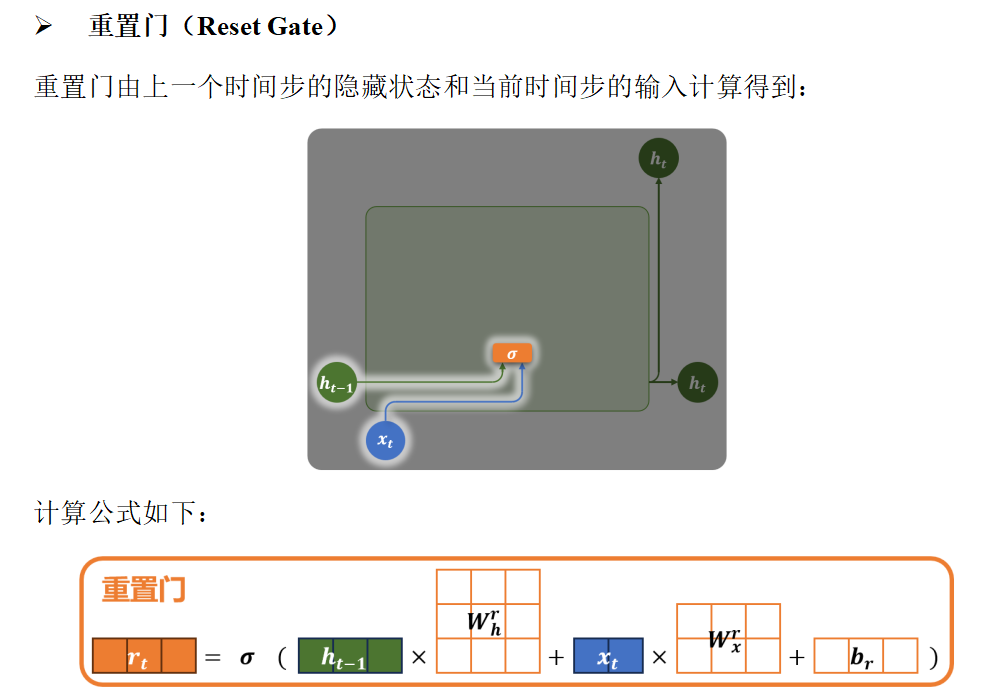
$$\boxed{r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)}$$


**每一项含义**：

| 项 | 含义 |
|---|------|
| $x_t$ | 当前时刻的输入（词向量） |
| $h_{t-1}$ | 上一时刻的隐藏状态 |
| $W_r, U_r$ | 可学习的权重矩阵 |
| $b_r$ | 偏置 |
| $\sigma$ | sigmoid 函数，输出 (0, 1) |
| $r_t$ | 重置门，shape 与 $h_t$ 相同，每个元素控制一个维度 |

**作用**：$r_t$ 用于下一步（公式三）中，决定「计算候选状态时，上一步记忆能保留多少」。

```
r_t ≈ 0  ->  几乎忽略上一步记忆  ->  像重新开始
r_t ≈ 1  ->  全量保留上一步记忆  ->  和普通 RNN 类似
``
**直觉**：当模型看到句号、换话题等信号时，r_t 会学会接近 0，让候选状态忘掉之前的内容。

## 4. 公式二：更新门
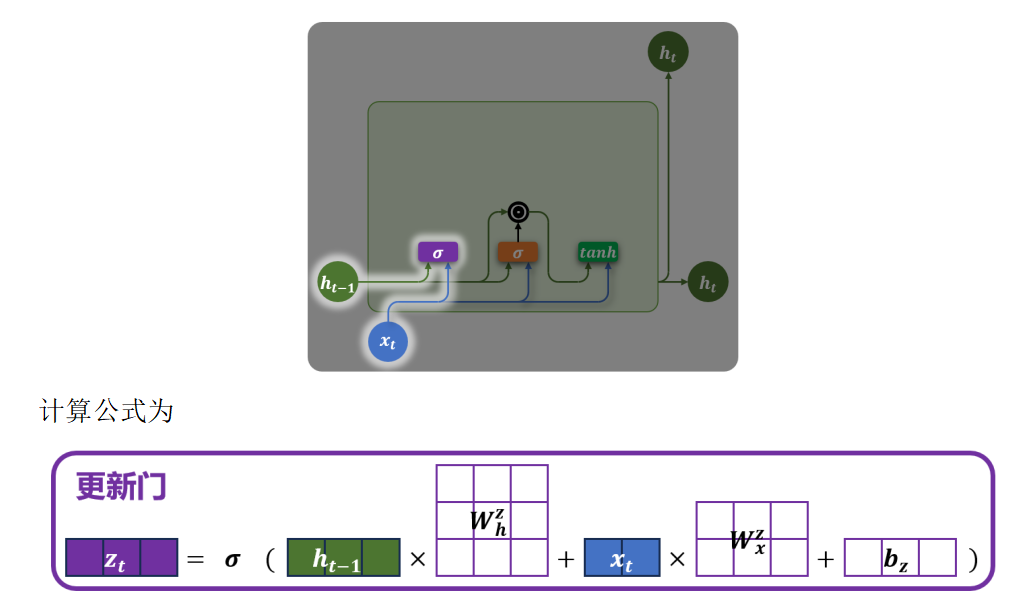
$$\boxed{z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)}$$

**每一项含义**：结构与重置门完全一样，只是参数不同（$W_z, U_z, b_z$）。

**作用**：$z_t$ 用于最后一步（公式四），决定「最终隐状态中，旧记忆和新候选各占多少比例」。

```
z_t ≈ 0  ->  最终状态 ≈ 旧记忆（不学新东西）
z_t ≈ 1  ->  最终状态 ≈ 新候选（完全替换）
```

**直觉**：当遇到重要的新信息时，z_t 接近 1，大幅更新记忆；遇到无关词时，z_t 接近 0，保持旧记忆不变。

**重置门 vs 更新门**：

| | 重置门 $r_t$ | 更新门 $z_t$ |
|---|---|---|
| 作用阶段 | 计算候选状态时 | 合并新旧状态时 |
| 控制的是 | 旧记忆对候选状态的影响 | 新旧状态的混合比例 |
| 比喻 | 想多少回忆过去 | 想多大程度接受新信息 |

## 5. 公式三：候选隐状态
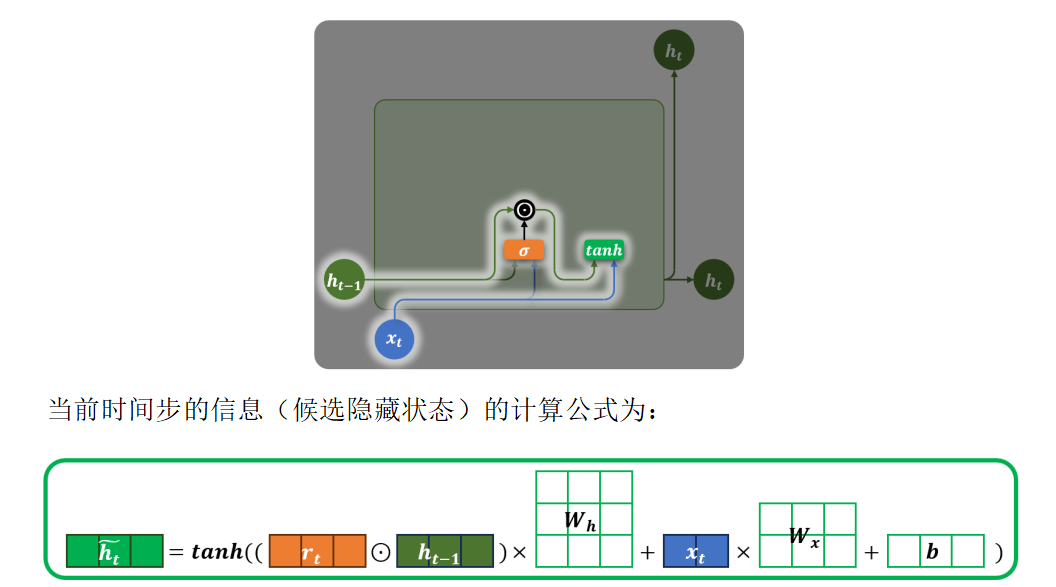
$$\boxed{\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)}$$

**每一项含义**：

| 项 | 含义 |
|---|------|
| $x_t$ | 当前输入 |
| $r_t \odot h_{t-1}$ | 用重置门过滤后的旧记忆 |
| $W_h, U_h, b_h$ | 可学习参数 |
| $\tanh$ | 激活函数，输出 (-1, 1) |
| $\tilde{h}_t$ | 候选新状态（还不是最终结果）|

**关键**：`r_t ⊙ h_{t-1}` 这一项。

```
普通 RNN：候选 = tanh(Wx_t + W·h_{t-1})           <- 全量使用旧记忆
GRU：     候选 = tanh(Wx_t + W·(r_t ⊙ h_{t-1}))  <- 选择性使用旧记忆
```

$\tilde{h}_t$ 是「如果要更新，打算更新成什么」——但还没真正更新。

## 6. 公式四：新隐藏状态（最终结果）
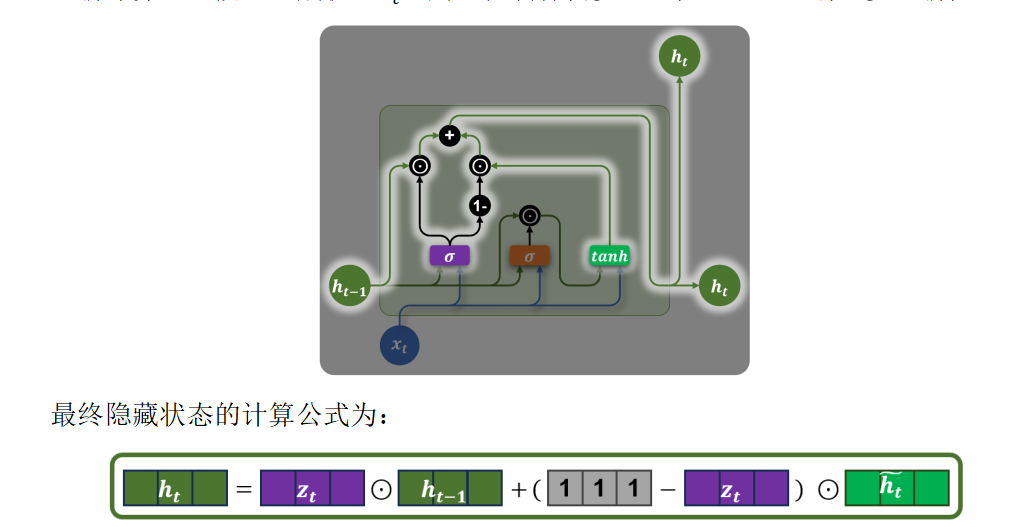
$$\boxed{h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t}$$

**每一项含义**：

| 项 | 含义 |
|---|------|
| $(1-z_t) \odot h_{t-1}$ | 保留旧记忆的比例（更新门关着，记忆不变） |
| $z_t \odot \tilde{h}_t$ | 接受新候选的比例（更新门开着，注入新信息） |
| $h_t$ | 最终输出的新隐藏状态 |

**这是 GRU 最关键的设计：线性插值**

```
z_t = 0.0  ->  h_t = 1.0 * h_{t-1} + 0.0 * h_tilde  = h_{t-1}  (完全不变)
z_t = 0.5  ->  h_t = 0.5 * h_{t-1} + 0.5 * h_tilde  (各半混合)
z_t = 1.0  ->  h_t = 0.0 * h_{t-1} + 1.0 * h_tilde  = h_tilde  (完全替换)
```

**为什么这能解决梯度消失？**

当 $z_t \approx 0$ 时：
$$h_t \approx h_{t-1}$$

梯度直接从 $h_t$ 流回 $h_{t-1}$，不经过任何非线性变换，**梯度不衰减**。

这就是「高速公路」——信息和梯度可以无损地跨越多个时间步。

```
RNN 的梯度路径：
  h10 -> tanh' -> h9 -> tanh' -> ... -> h1  (每步都乘<1的数，衰减)

GRU 的梯度路径（z≈0时）：
  h10 -> 直通  -> h9 -> 直通  -> ... -> h1  (近似恒等，不衰减)
```

## 7. 四个公式总览
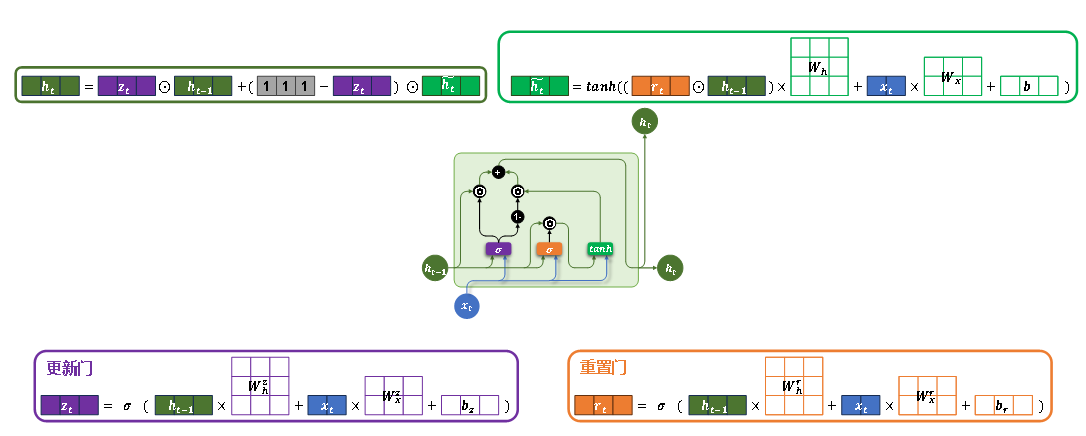
| 编号 | 名称 | 公式 |
|------|------|------|
| ① | 重置门 | $r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)$ |
| ② | 更新门 | $z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)$ |
| ③ | 候选隐状态 | $\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)$ |
| ④ | 新隐藏状态 | $h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$ |

**计算顺序**：① → ② → ③ → ④，每个时间步做一遍。

**参数总结**：

| 参数 | 形状 | 属于哪个公式 |
|------|------|------|
| $W_r, U_r, b_r$ | W: (hidden, input), U: (hidden, hidden) | 重置门 |
| $W_z, U_z, b_z$ | 同上 | 更新门 |
| $W_h, U_h, b_h$ | 同上 | 候选状态 |

**GRU 参数量 = 3 × (input×hidden + hidden×hidden + hidden) = 3 × RNN 参数量**

比 RNN 多了 3 倍，但比 LSTM（4 个门）少了 1/4。

In [1]:
import torch
import torch.nn as nn

input_size = 64
hidden_size = 128

rnn = nn.RNN(input_size, hidden_size, batch_first=True)
gru = nn.GRU(input_size, hidden_size, batch_first=True)

rnn_params = sum(p.numel() for p in rnn.parameters())
gru_params = sum(p.numel() for p in gru.parameters())

print('RNN 参数量:', rnn_params)
print('GRU 参数量:', gru_params)
print('GRU / RNN =', gru_params / rnn_params, '(应该约等于 3)')

# 手算验证
# RNN: W_xh(64*128) + W_hh(128*128) + b_ih(128) + b_hh(128)
rnn_manual = input_size*hidden_size + hidden_size*hidden_size + hidden_size + hidden_size
print('\nRNN 手算:', rnn_manual)
# GRU: 3 * (W_x + W_h + b)
gru_manual = 3 * (input_size*hidden_size + hidden_size*hidden_size + hidden_size + hidden_size)
print('GRU 手算:', gru_manual)

RNN 参数量: 24832
GRU 参数量: 74496
GRU / RNN = 3.0 (应该约等于 3)

RNN 手算: 24832
GRU 手算: 74496


## 8. PyTorch nn.GRU 用法

**接口和 nn.RNN 几乎完全一样**，直接替换即可：

```python
gru = nn.GRU(
    input_size=64,     # 词向量维度
    hidden_size=128,   # 隐藏状态维度
    num_layers=1,      # 层数
    batch_first=True,  # (batch, seq_len, input_size)
    bidirectional=False
)

x = torch.randn(8, 10, 64)        # (batch=8, seq_len=10, input=64)
output, hn = gru(x)

print(output.shape)   # (8, 10, 128)  每个时刻的隐藏状态
print(hn.shape)       # (1, 8, 128)   最后一个时刻的隐藏状态
```

**输入输出形状与 RNN 完全一致**：

| 输入/输出 | 形状 | 说明 |
|---|---|---|
| `x` | (batch, seq_len, input_size) | 词向量序列 |
| `output` | (batch, seq_len, hidden_size) | 每个时刻的 h |
| `hn` | (num_layers, batch, hidden_size) | 最后时刻的 h |

**从 RNN 升级到 GRU 只需改一行**：
```python
# 原来
self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
# 改成
self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)  # 其他代码不变
```

In [ ]:
import torch
import torch.nn as nn

gru = nn.GRU(input_size=64, hidden_size=128, batch_first=True)

x = torch.randn(8, 10, 64)   # batch=8, seq_len=10, input=64
output, hn = gru(x)

print('output:', output.shape)   # (8, 10, 128)
print('hn:    ', hn.shape)       # (1, 8, 128)

# 验证 hn 等于 output 的最后一个时刻
print('\nhn 等于 output 最后一步?', torch.allclose(hn[0], output[:, -1, :]))

## 9. GRU 序列分类：完整模型

把 U06 的 RNN 分类器直接替换为 GRU：

```python
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)  # 唯一改动
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)  词索引
        vecs = self.embedding(x)          # (batch, seq_len, embed_dim)
        _, hn = self.gru(vecs)            # hn: (1, batch, hidden_dim)
        out = self.fc(hn.squeeze(0))      # (batch, num_classes)
        return out
```

**形状流转**（以 batch=4, seq_len=6, embed=32, hidden=64, classes=2 为例）：

```
x          (4, 6)       词索引
   -> Embedding
vecs       (4, 6, 32)   每个词的向量
   -> GRU
hn         (1, 4, 64)   最后时刻的记忆
   -> squeeze(0)
hn         (4, 64)      去掉层维度
   -> Linear
logits     (4, 2)       两个类别的分数
```

## 10. GRU vs RNN vs LSTM 对比

| | RNN | GRU | LSTM |
|---|---|---|---|
| 门的数量 | 0 | 2（重置、更新） | 3（遗忘、输入、输出）|
| 参数量（相对） | 1x | 3x | 4x |
| 隐状态 | $h_t$ | $h_t$ | $h_t$ + $c_t$（细胞状态）|
| 解决梯度消失 | 否 | 是 | 是 |
| 速度 | 最快 | 中等 | 最慢 |
| 实用性 | 较弱 | **常用** | **常用** |

**选择建议**：
- 大多数 NLP 任务：GRU 和 LSTM 效果相近，**优先试 GRU**（更简单、更快）
- 超长序列（>100 词）：LSTM 略优
- 现代方案：Transformer 在大数据上碾压两者，但序列短时 GRU 仍有竞争力

**本课程选 GRU 的原因**：公式更简洁，适合入门理解门控机制，且在我们要做的中文翻译任务（短句）上效果足够。

## 11. 本单元小结

| 概念 | 一句话 |
|---|---|
| 梯度消失 | tanh 导数 <1，连乘后梯度趋于 0，远处词学不到 |
| 重置门 $r_t$ | 决定候选状态里，旧记忆保留多少 |
| 更新门 $z_t$ | 决定新旧状态的混合比例 |
| 候选状态 $\tilde{h}_t$ | 打算更新成什么 |
| 新隐状态 $h_t$ | 线性插值合并旧记忆和候选状态 |
| 解决梯度消失的方式 | $z_t \approx 0$ 时 $h_t \approx h_{t-1}$，梯度直通 |
| PyTorch 用法 | `nn.GRU` 接口与 `nn.RNN` 完全一致 |

**四个公式记忆口诀**：
```
① 重置门  r = sigmoid(...)        我要忘多少过去
② 更新门  z = sigmoid(...)        我要接受多少新信息
③ 候选值  h~ = tanh(... r*h ...)  如果更新，更新成这个
④ 新状态  h = (1-z)*h + z*h~     按比例混合新旧
```

下一单元：**U08 Seq2Seq + Teacher Forcing** —— 把 GRU 用于翻译任务，实现 Encoder-Decoder 架构。